In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [8]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Проверяем формат столбцов

In [9]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [10]:
print(df.head())

        Дата  Склад Контрагент Номенклатура  Количество
0 2018-01-04      1  address_0    product_0           4
1 2018-01-04      1  address_0    product_1           4
2 2018-01-04      1  address_0    product_2           5
3 2018-01-04      1  address_0    product_3          10
4 2018-01-04      1  address_0    product_4           2


Сразу переведем столбец "Дата" в правильный формат

In [11]:
grouped_df = df.groupby('Дата', as_index=False)['Количество'].sum()

Сгруппируйте данные по дате, посчитайте количество продаж

Вывести несколько первых строк сгруппированных данных

In [12]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

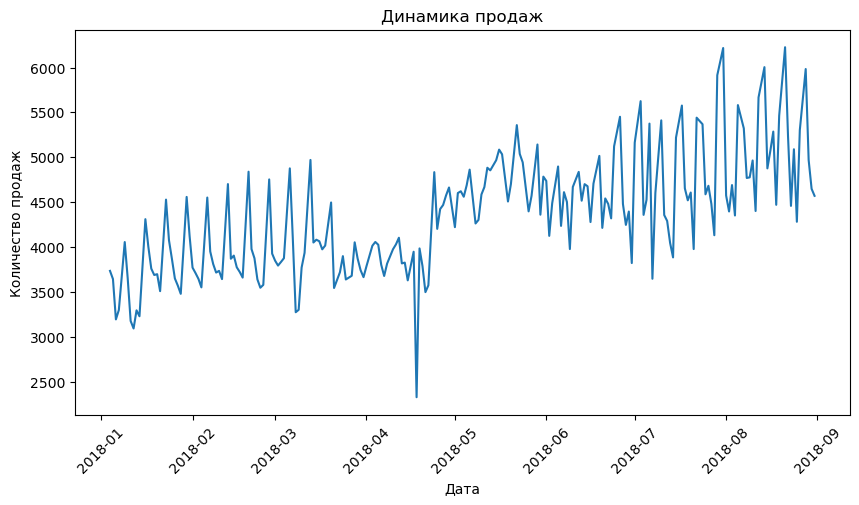

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.title('Динамика продаж')
plt.xticks(rotation=45)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
В целом делa у бизнеса идут хорошо — к концу лета товаров продают заметно больше, чем в начале года.
График похож на забор или пилу. Это значит, что продажи скачут каждую неделю: например, в выходные — много, в будни — мало.
В середине апреля случилась какая-то беда — продажи резко упали почти до нуля, хотя потом всё быстро восстановилось. К концу лета график начинает «скакать» еще сильнее — пики становятся выше, а падения — резче.
Бизнес растет, но работает нестабильно, рывками.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [14]:
df[df['Количество'] == df['Количество'].max()]

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [15]:
df['weekday'] = df['Дата'].dt.weekday
df['month'] = df['Дата'].dt.month

filtered = df[
    (df['weekday'] == 2) &  # среда
    (df['month'].isin([6, 7, 8])) &
    (df['Склад'] == 3)
]

top_product = (
    filtered.groupby('Номенклатура')['Количество']
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

top_product

Номенклатура
product_1    2267
Name: Количество, dtype: int64

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [3]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


         Дата  Средняя температура
0  2017-12-31              -7.8750
1  2018-01-01              -9.4625
2  2018-01-02              -9.5125
3  2018-01-03             -11.4625
4  2018-01-04             -14.0750


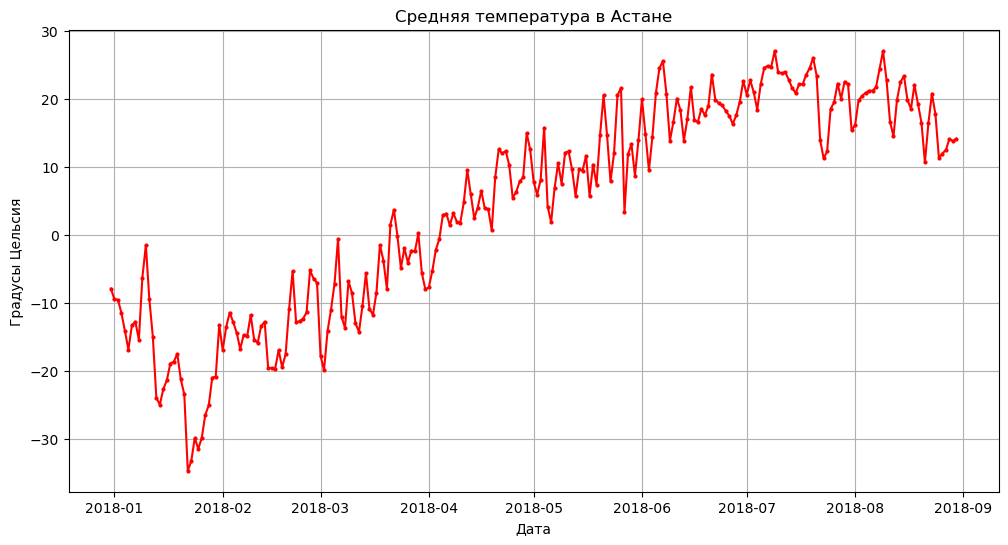

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('astana_weather.xls', skiprows=6)

time_column = df.columns[0] 
temp_column = 'T'

df[time_column] = pd.to_datetime(df[time_column], dayfirst=True)
df['Дата'] = df[time_column].dt.date 

daily_temp = df.groupby('Дата')[temp_column].mean().reset_index()
daily_temp.columns = ['Дата', 'Средняя температура'] 

print(daily_temp.head())

plt.figure(figsize=(12, 6))
plt.plot(daily_temp['Дата'], daily_temp['Средняя температура'], color='red', marker='o', markersize=2)
plt.title('Средняя температура в Астане')
plt.xlabel('Дата')
plt.ylabel('Градусы Цельсия')
plt.grid(True)
plt.show()